In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features
from src.preprocessing import scale_features

In [3]:
train_data = load_data("../data/raw/KDDTrain+.txt")
test_data  = load_data("../data/raw/KDDTest+.txt")
train_data = encode_features(train_data)
test_data  = encode_features(test_data)

X_train, y_train = split_features(train_data)
X_test,  y_test  = split_features(test_data)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(X_train)
x_test  = scaler.transform(X_test)

In [5]:
from src.isolation_forest_model import train_isolation_forest

model = train_isolation_forest(x_train)

In [6]:
from src.isolation_forest_model import detect_anomalies

predictions = detect_anomalies(model,x_test)

In [7]:
import numpy as np

np.unique(predictions, return_counts = True)

(array([-1,  1]), array([ 8025, 14519]))

In [8]:
test_data['anomaly'] = predictions

In [9]:
test_data[test_data['anomaly'] == -1].head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly
1,0,1,45,1,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,-1
4,1,1,55,2,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,mscan,-1
6,0,1,49,9,1022,387,0,0,0,0,...,0.11,0.72,0.00,0.00,0.00,0.00,0.72,0.04,normal,-1
13,0,1,55,5,0,0,0,0,0,0,...,0.73,0.07,0.00,0.00,0.69,0.95,0.02,0.00,neptune,-1
14,37,1,55,9,773,364200,0,0,0,0,...,0.16,0.05,0.03,0.04,0.00,0.77,0.00,0.07,normal,-1
18,0,2,45,9,45,44,0,0,0,0,...,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,normal,-1
19,0,1,45,1,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,-1
20,0,1,28,1,0,0,0,0,0,0,...,0.07,0.05,0.00,0.00,0.00,0.00,1.00,1.00,neptune,-1
21,0,1,43,5,0,0,0,0,0,0,...,0.34,0.01,0.01,0.00,1.00,1.00,0.00,0.00,mscan,-1
24,0,1,5,1,0,0,0,0,0,0,...,0.03,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,-1


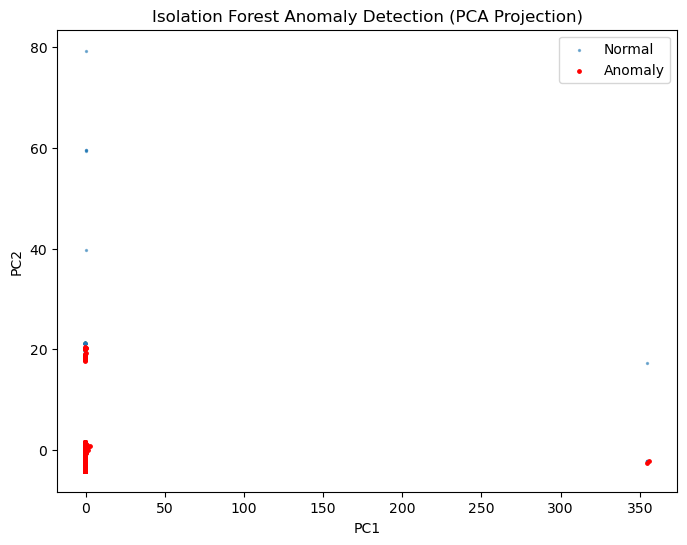

In [14]:
import matplotlib.pyplot as plt

normal = x_pca[predictions == 1]
anomaly = x_pca[predictions == -1]

plt.figure(figsize=(8,6))

plt.scatter(normal[:,0], normal[:,1], s=2, label="Normal", alpha=0.5)
plt.scatter(anomaly[:,0], anomaly[:,1], s=6, color="red", label="Anomaly")

plt.title("Isolation Forest Anomaly Detection (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.show()

In [17]:
# The first two principal components capture ~61% of the variance.
# While sufficient for visualization, some overlap occurs due to the
# high dimensional nature of the NSL-KDD dataset.

In [18]:
import joblib

joblib.dump(model, "../results/isolation_forest_model.pkl")

['../results/isolation_forest_model.pkl']

In [19]:
test_data["attack"] = test_data["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

In [20]:
test_data["predicted_attack"] = (
    test_data["anomaly"].apply(lambda x: 1 if x == -1 else 0)
)

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_data['attack'],test_data['predicted_attack'])
print(cm)

[[8868  843]
 [5651 7182]]


In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    test_data["attack"],
    test_data["predicted_attack"]
))

              precision    recall  f1-score   support

           0       0.61      0.91      0.73      9711
           1       0.89      0.56      0.69     12833

    accuracy                           0.71     22544
   macro avg       0.75      0.74      0.71     22544
weighted avg       0.77      0.71      0.71     22544



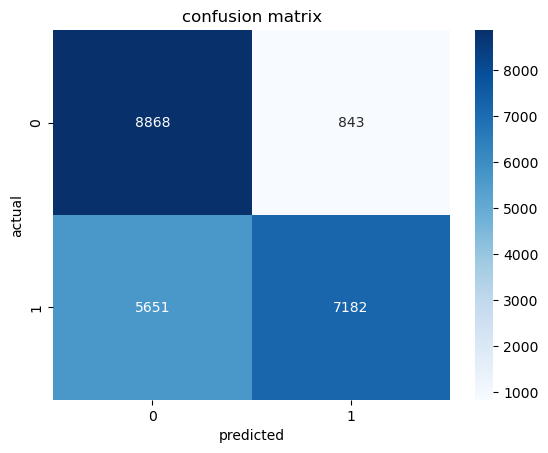

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot = True, fmt = 'd', cmap = "Blues")
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

In [24]:
# Isolation Forest assumes anomalies are rare events.
# However, in the NSL-KDD dataset attacks constitute nearly half of the traffic.
# Therefore the algorithm struggles to identify many attack instances.

In [27]:
from src.dbscan_model import train_dbscan

dbscan_labels = train_dbscan(x_train)

In [28]:
train_data["dbscan_attack"] = (dbscan_labels == -1).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

train_data["attack"] = (y_train != "normal").astype(int)

print(confusion_matrix(train_data["attack"], train_data["dbscan_attack"]))
print(classification_report(train_data["attack"], train_data["dbscan_attack"]))

[[63907  3436]
 [57415  1215]]
              precision    recall  f1-score   support

           0       0.53      0.95      0.68     67343
           1       0.26      0.02      0.04     58630

    accuracy                           0.52    125973
   macro avg       0.39      0.48      0.36    125973
weighted avg       0.40      0.52      0.38    125973



In [ ]:
# DBSCAN performs poorly on the NSL-KDD dataset due to the high
# dimensionality of the feature space. Density-based clustering
# methods rely on meaningful distance metrics, which degrade in
# high-dimensional environments. As a result, most data points are
# assigned to clusters and very few are labeled as noise (anomalies).

In [23]:
# Isolation Forest performs significantly better than DBSCAN on the NSL-KDD dataset
# because tree-based isolation methods handle high-dimensional data more effectively
# than density-based clustering algorithms.

In [29]:
scores = model.decision_function(x_test.values)
test_data["anomaly_score"] = scores

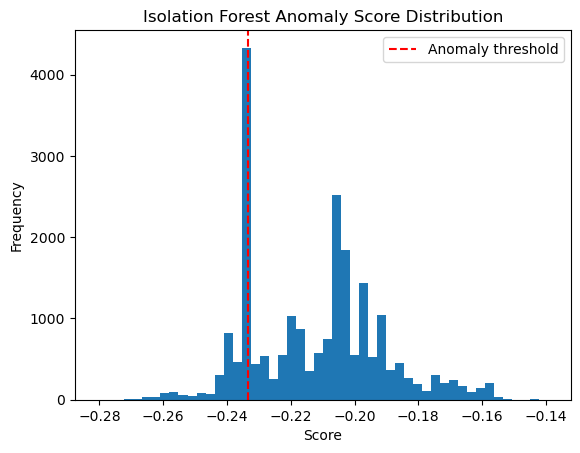

In [34]:
import matplotlib.pyplot as plt
import numpy as np

scores = model.decision_function(X_test.values)

test_data["anomaly_score"] = scores

threshold = np.percentile(scores, 20)

plt.hist(scores, bins=50)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.axvline(threshold, color="red", linestyle="--", label="Anomaly threshold")
plt.legend()

plt.savefig("../results/anomaly_score_distribution.png")

plt.show()

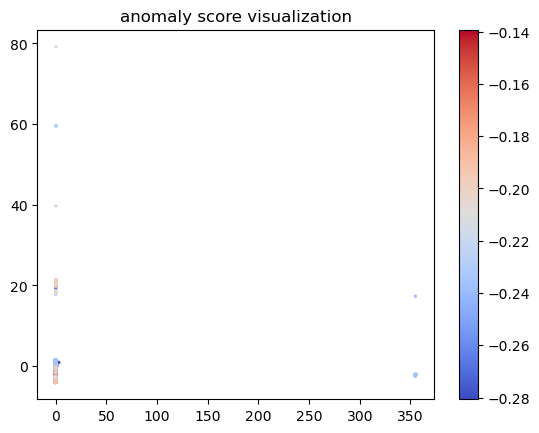

In [35]:
plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c = test_data["anomaly_score"],
    cmap = "coolwarm",
    s=2
)
plt.colorbar()
plt.title("anomaly score visualization")
plt.show()

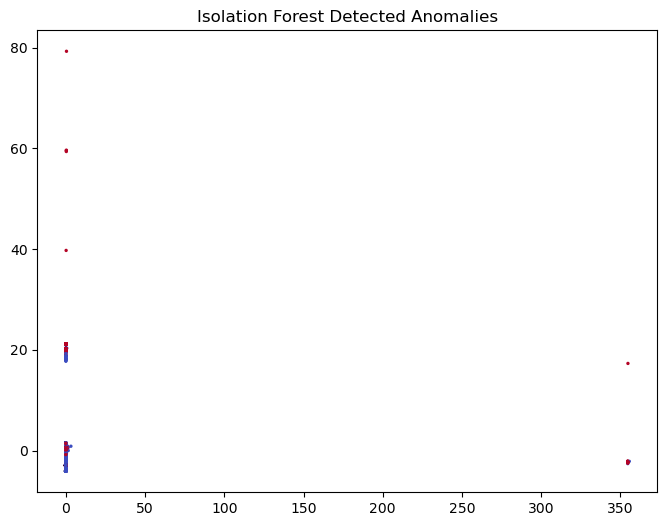

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=test_data["anomaly"],
    cmap="coolwarm",
    s=2
)

plt.title("Isolation Forest Detected Anomalies")

plt.show()

In [37]:
test_data.sort_values("anomaly_score").head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly,attack,predicted_attack,dbscan_attack,anomaly_score
20734,988,1,55,9,1773,32209,0,0,0,4,...,0.33,0.77,0.02,0.01,rootkit,-1,1,1,1,-0.280678
11765,1776,1,55,9,3061,54942,0,0,0,15,...,0.00,0.00,0.00,0.00,multihop,-1,1,1,1,-0.280169
2745,242,1,55,9,504,27200,0,0,1,2,...,0.00,0.00,0.00,0.00,xterm,-1,1,1,1,-0.272110
4352,135,1,55,9,353,5769,0,0,0,4,...,0.48,0.86,0.02,0.01,ps,-1,1,1,1,-0.271705
12525,314,1,55,9,2602,3167,0,0,0,1,...,0.00,0.00,0.00,0.00,xterm,-1,1,1,1,-0.271229
10995,804,1,55,9,1589,36386,0,0,3,7,...,0.00,0.00,0.06,0.25,rootkit,-1,1,1,1,-0.271212
9064,72,1,55,9,2783,15142,0,0,0,10,...,0.00,0.00,0.98,0.98,buffer_overflow,-1,1,1,1,-0.268861
12486,31,1,55,9,197,1644,0,0,0,1,...,0.63,0.94,0.02,0.00,ps,-1,1,1,1,-0.268509
3621,184,1,55,9,2923,5285,0,0,1,2,...,0.00,0.00,0.00,0.00,xterm,-1,1,1,1,-0.268014
967,1964,1,55,9,3760,29364,0,0,0,2,...,0.00,0.00,0.83,0.00,buffer_overflow,-1,1,1,1,-0.267197


In [38]:
test_data["label"].value_counts().head(10)

label
normal          9711
neptune         4657
guess_passwd    1231
mscan            996
warezmaster      944
apache2          737
satan            735
processtable     685
smurf            665
back             359
Name: count, dtype: int64

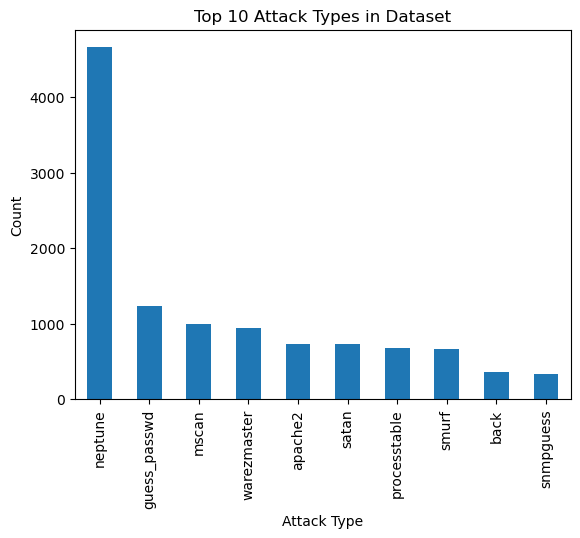

In [39]:
import matplotlib.pyplot as plt

attack_counts = test_data[test_data["label"] != "normal"]["label"].value_counts().head(10)

attack_counts.plot(kind="bar")

plt.title("Top 10 Attack Types in Dataset")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

In [40]:
anomalies = test_data[test_data['anomaly'] == -1]
anomalies['label'].value_counts().head(10)

label
neptune         1928
mscan            992
normal           843
apache2          734
satan            734
processtable     641
warezmaster      623
smurf            390
back             353
saint            217
Name: count, dtype: int64

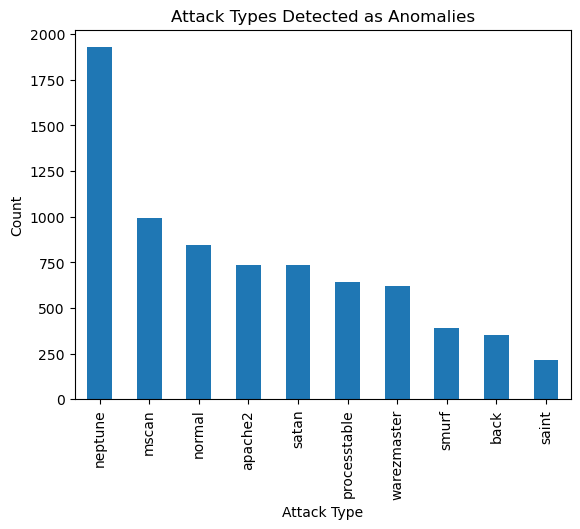

In [41]:
anomalies['label'].value_counts().head(10).plot(kind='bar')

plt.title("Attack Types Detected as Anomalies")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

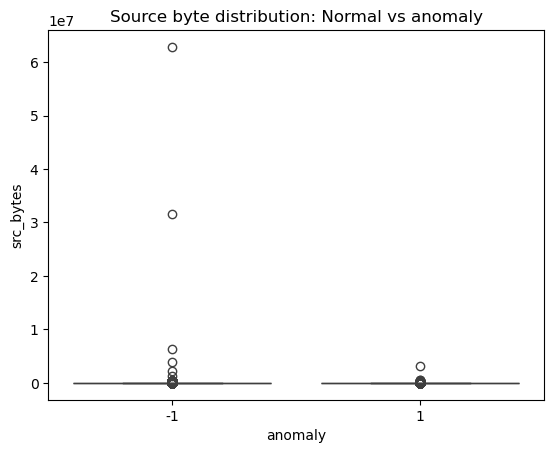

In [42]:
import seaborn as sns

sns.boxplot(x = test_data['anomaly'],y = test_data['src_bytes'])
plt.title("Source byte distribution: Normal vs anomaly")
plt.show()

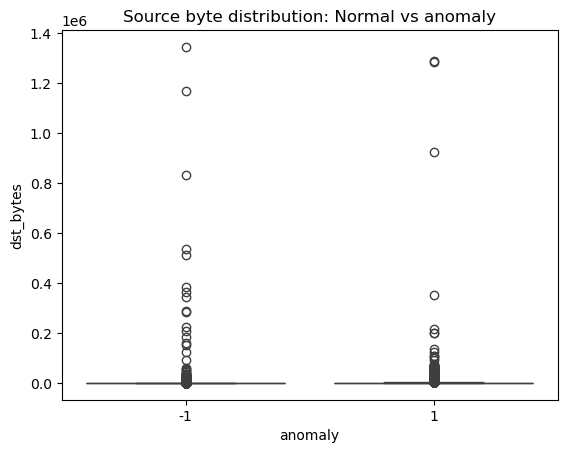

In [43]:
sns.boxplot(x = test_data['anomaly'],y = test_data['dst_bytes'])
plt.title("Source byte distribution: Normal vs anomaly")
plt.show()

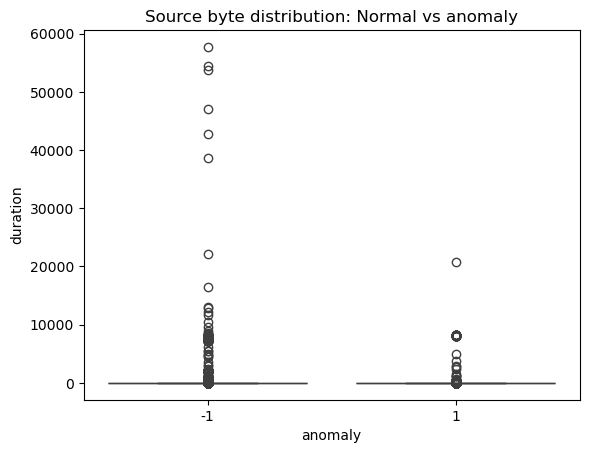

In [44]:
sns.boxplot(x = test_data['anomaly'],y = test_data['duration'])
plt.title("Source byte distribution: Normal vs anomaly")
plt.show()

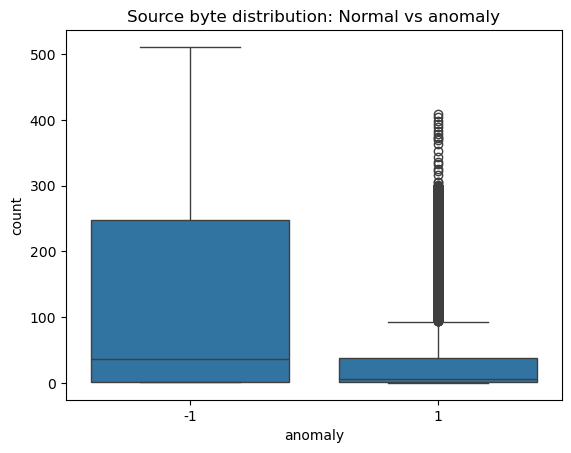

In [45]:
sns.boxplot(x = test_data['anomaly'],y = test_data['count'])
plt.title("Source byte distribution: Normal vs anomaly")
plt.show()

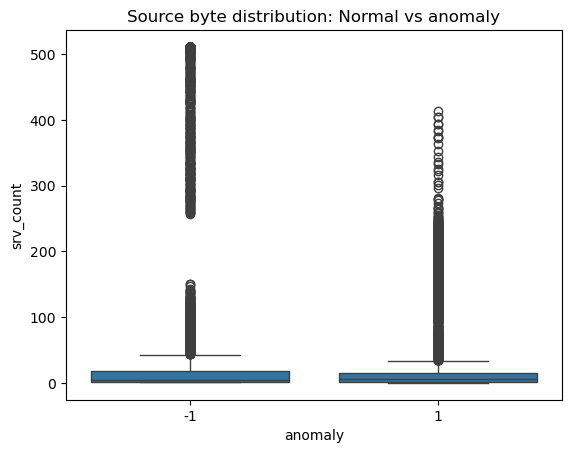

In [46]:
sns.boxplot(x = test_data['anomaly'],y = test_data['srv_count'])
plt.title("Source byte distribution: Normal vs anomaly")
plt.show()

In [47]:
numeric_data = test_data.select_dtypes(include = ["int64","float64"])

normal = numeric_data[test_data["anomaly"] == 1]
anomaly = numeric_data[test_data["anomaly"] == -1]

diff = (anomaly.mean() - normal.mean()).abs().sort_values(ascending = False)
diff.head(10)

src_bytes             25011.460320
dst_bytes               935.151970
duration                529.599609
count                    90.771285
dst_host_srv_count       83.155002
dst_host_count           42.565143
srv_count                35.238585
service                   6.321612
flag                      2.782155
anomaly                   2.000000
dtype: float64

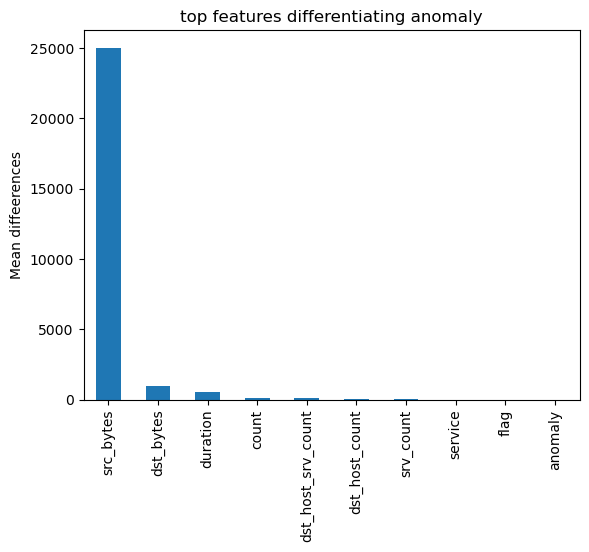

In [48]:
diff.head(10).plot(kind = 'bar')

plt.title("top features differentiating anomaly")
plt.ylabel("Mean diffeerences")
plt.show()

In [49]:
test_data.sort_values("anomaly_score").head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly,attack,predicted_attack,dbscan_attack,anomaly_score
20734,988,1,55,9,1773,32209,0,0,0,4,...,0.33,0.77,0.02,0.01,rootkit,-1,1,1,1,-0.280678
11765,1776,1,55,9,3061,54942,0,0,0,15,...,0.00,0.00,0.00,0.00,multihop,-1,1,1,1,-0.280169
2745,242,1,55,9,504,27200,0,0,1,2,...,0.00,0.00,0.00,0.00,xterm,-1,1,1,1,-0.272110
4352,135,1,55,9,353,5769,0,0,0,4,...,0.48,0.86,0.02,0.01,ps,-1,1,1,1,-0.271705
12525,314,1,55,9,2602,3167,0,0,0,1,...,0.00,0.00,0.00,0.00,xterm,-1,1,1,1,-0.271229
10995,804,1,55,9,1589,36386,0,0,3,7,...,0.00,0.00,0.06,0.25,rootkit,-1,1,1,1,-0.271212
9064,72,1,55,9,2783,15142,0,0,0,10,...,0.00,0.00,0.98,0.98,buffer_overflow,-1,1,1,1,-0.268861
12486,31,1,55,9,197,1644,0,0,0,1,...,0.63,0.94,0.02,0.00,ps,-1,1,1,1,-0.268509
3621,184,1,55,9,2923,5285,0,0,1,2,...,0.00,0.00,0.00,0.00,xterm,-1,1,1,1,-0.268014
967,1964,1,55,9,3760,29364,0,0,0,2,...,0.00,0.00,0.83,0.00,buffer_overflow,-1,1,1,1,-0.267197
